In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

In [40]:

# Load main events file
events = pd.read_csv('events.csv')
print(events.head())
print(events.info())


       timestamp  visitorid event  itemid  transactionid
0  1433221332117     257597  view  355908            NaN
1  1433224214164     992329  view  248676            NaN
2  1433221999827     111016  view  318965            NaN
3  1433221955914     483717  view  253185            NaN
4  1433221337106     951259  view  367447            NaN
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      int64  
 1   visitorid      int64  
 2   event          object 
 3   itemid         int64  
 4   transactionid  float64
dtypes: float64(1), int64(3), object(1)
memory usage: 105.1+ MB
None


In [41]:
# EDA

print(events.shape)
print(events.columns)


(2756101, 5)
Index(['timestamp', 'visitorid', 'event', 'itemid', 'transactionid'], dtype='object')


In [42]:
print(events.isnull().sum())


timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2733644
dtype: int64


In [43]:
print(events['event'].value_counts())


event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64


In [44]:
purchases = events[events['event'] == 'transaction']
print(purchases.head())
print("Unique customers:", purchases['visitorid'].nunique())

clv_per_user = purchases.groupby('visitorid').size().reset_index(name='num_purchases')
print(clv_per_user.describe())


         timestamp  visitorid        event  itemid  transactionid
130  1433222276276     599528  transaction  356475         4000.0
304  1433193500981     121688  transaction   15335        11117.0
418  1433193915008     552148  transaction   81345         5444.0
814  1433176736375     102019  transaction  150318        13556.0
843  1433174518180     189384  transaction  310791         7244.0
Unique customers: 11719
          visitorid  num_purchases
count  1.171900e+04   11719.000000
mean   7.099856e+05       1.916290
std    4.058287e+05       8.850529
min    1.720000e+02       1.000000
25%    3.591195e+05       1.000000
50%    7.183140e+05       1.000000
75%    1.062739e+06       1.000000
max    1.407398e+06     559.000000


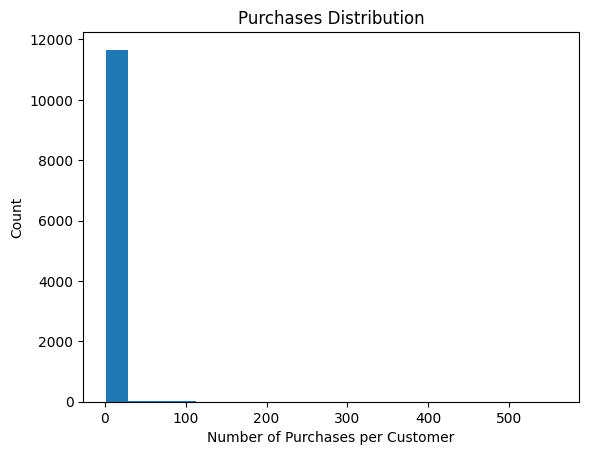

In [45]:
plt.hist(clv_per_user['num_purchases'], bins=20)
plt.xlabel('Number of Purchases per Customer')
plt.ylabel('Count')
plt.title('Purchases Distribution')
plt.show()


In [46]:
print(purchases['transactionid'].describe())
print(purchases['transactionid'].nunique())
print(purchases['transactionid'].head(20))


count    22457.000000
mean      8826.497796
std       5098.996290
min          0.000000
25%       4411.000000
50%       8813.000000
75%      13224.000000
max      17671.000000
Name: transactionid, dtype: float64
17672
130      4000.0
304     11117.0
418      5444.0
814     13556.0
843      7244.0
1214     8796.0
1215     8796.0
1234     5216.0
1350    11713.0
1512     2415.0
1690    15915.0
1711    14924.0
1871    11615.0
2075    11956.0
2142     3051.0
2237    11413.0
2242     1343.0
2292    11138.0
2315     1798.0
2316     1798.0
Name: transactionid, dtype: float64


In [47]:
#  feature

clv = purchases.groupby('visitorid').agg(
    purchase_count=('itemid', 'size'),
    first_purchase=('timestamp', 'min'),
    last_purchase=('timestamp', 'max'),
    product_diversity=('itemid', 'nunique')
).reset_index()

clv['recency'] = purchases['timestamp'].max() - clv['last_purchase']


In [48]:
X = clv.drop(['visitorid', 'purchase_count'], axis=1)
y = clv['purchase_count']


In [49]:
# train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


Train shape: (9375, 4), Test shape: (2344, 4)


In [50]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [51]:
# Train model
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

# Predict
y_pred_dt = dt.predict(X_test)

# Metrics
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print(f"Decision Tree RMSE: {rmse_dt:.2f}")
print(f"Decision Tree R^2: {r2_dt:.2f}")

Decision Tree RMSE: 1.52
Decision Tree R^2: 0.97


In [52]:
# Train XGBoost regressor
xgb = XGBRegressor(random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb.predict(X_test)

# Metrics
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost RMSE: {rmse_xgb:.2f}")
print(f"XGBoost R^2: {r2_xgb:.2f}")

XGBoost RMSE: 0.81
XGBoost R^2: 0.99


In [53]:
# Linear Regression
y_pred_lr = lr.predict(X_test)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression RMSE: {rmse_lr:.2f}")
print(f"Linear Regression R^2: {r2_lr:.2f}")

# Repeat for Decision Tree
y_pred_dt = dt.predict(X_test)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print(f"Decision Tree RMSE: {rmse_dt:.2f}")
print(f"Decision Tree R^2: {r2_dt:.2f}")

# Repeat for XGBoost
y_pred_xgb = xgb.predict(X_test)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost RMSE: {rmse_xgb:.2f}")
print(f"XGBoost R^2: {r2_xgb:.2f}")

Linear Regression RMSE: 0.53
Linear Regression R^2: 1.00
Decision Tree RMSE: 1.52
Decision Tree R^2: 0.97
XGBoost RMSE: 0.81
XGBoost R^2: 0.99
